# RLM Surrogate Ablation Explorer

Interactive exploration of results from `run_ablation.py` (feature-mode
ablation) and/or `run_ablation_lhs_points.py` (LHS sample-density
ablation).

**Built for in-progress runs.** These ablations take a long time
(multi-day per `(variant, seed, holdout_fids)` combination even spread
across several GPUs), so this notebook works from whatever
`ablation_result.json` files exist *right now* under `results/ablation/`
and/or `results/ablation_lhs_points/` -- it does **not** wait for
`ablation_summary.json` (that file is only written once *every*
combination in a run's requested matrix has finished). Just re-run the
notebook top to bottom any time to pick up newly-finished runs; no kernel
restart needed.

Each run directory holds one `(variant, seed, holdout_fids)` combination's
result -- see `run_ablation.py`'s / `run_ablation_lhs_points.py`'s module
docstrings for what each axis means, and `README.md` sections 5d/5e for
the full runbook.


In [16]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Point this at your results

Edit the paths below if your `--output-dir`s were different from the
README's examples. A missing directory is skipped, not an error --
handy if you've only run one of the two ablations so far.


In [17]:
RESULTS_DIRS = {
    "feature_mode": Path("/data/neocortex/rlm/results/ablation"),
    "lhs_points": Path("/data/neocortex/rlm/results/ablation_lhs_points"),
}

for study, path in RESULTS_DIRS.items():
    status = "found" if path.exists() else "NOT FOUND (skipping)"
    print(f"{study:<14} {path}  [{status}]")


feature_mode   /data/neocortex/rlm/results/ablation  [found]
lhs_points     /data/neocortex/rlm/results/ablation_lhs_points  [found]


## 2. Load every completed run

Scans for `ablation_result.json` (one per finished combination) rather
than the top-level `ablation_summary.json`, since that summary only gets
written once *every* combination in a matrix has finished -- with these
ablations still in progress, most of the signal lives in the per-run
files.

A file that fails to parse (a run killed mid-write) is skipped rather
than crashing the notebook. Runs from before `holdout_fids` was tracked
(older directory names with no `__holdout...` suffix) still load, just
labelled `"unknown (legacy run)"` so they don't silently get lumped in
with a real holdout region.


In [18]:
def load_results(results_dir: Path, study: str) -> pd.DataFrame:
    rows = []
    n_skipped = 0
    for f in sorted(results_dir.glob("**/ablation_result.json")):
        try:
            result = json.loads(f.read_text())
        except json.JSONDecodeError:
            n_skipped += 1
            continue
        if not isinstance(result, dict) or "spearman_rho" not in result:
            n_skipped += 1
            continue
        row = dict(result)
        row["study"] = study
        row["result_path"] = str(f)
        holdout = row.get("holdout_fids")
        row["holdout_label"] = (
            "-".join(map(str, holdout)) if holdout else "unknown (legacy run)"
        )
        wc = row.get("wall_clock_seconds") or {}
        row["wall_clock_total_h"] = sum(wc.values()) / 3600 if wc else np.nan
        instance_level = row.get("instance_level") or {}
        row["instance_level_spearman"] = instance_level.get("spearman_rho")
        rows.append(row)
    df = pd.DataFrame(rows)
    msg = f"[{study}] {len(df)} completed run(s) loaded from {results_dir}"
    if n_skipped:
        msg += f" ({n_skipped} unreadable/incomplete file(s) skipped)"
    print(msg)
    return df


frames = [
    load_results(path, study)
    for study, path in RESULTS_DIRS.items()
    if path.exists()
]
frames = [f for f in frames if len(f)]
all_results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
HAS_DATA = not all_results.empty

if not HAS_DATA:
    print(
        "\nNo ablation_result.json files found yet -- the cells below will "
        "just print a skip notice until at least one run finishes. Re-run "
        "this notebook later to pick them up."
    )

all_results.head()


[feature_mode] 45 completed run(s) loaded from /data/neocortex/rlm/results/ablation
[lhs_points] 36 completed run(s) loaded from /data/neocortex/rlm/results/ablation_lhs_points


,variant,seed,holdout_fids,n_train,n_val,n_test,instance_explosion,spearman_rho,kendall_tau,instance_level,wall_clock_seconds,run_dir,study,result_path,holdout_label,wall_clock_total_h,instance_level_spearman,n_lhs_points,feature_mode
0,lhs,0,"[13, 19]",72291,18881,2152,"{'n_no_aucs': 0, 'n_no_instance_mapping': 654,...",0.763583,0.580255,"{'n': 2152, 'spearman_rho': 0.6097532962902996...","{'pipeline': 767.2940242290497, 'train': 12334...",/data/neocortex/rlm/results/ablation/lhs__seed...,feature_mode,/data/neocortex/rlm/results/ablation/lhs__seed...,13-19,35.568388,0.609753,NaN,NaN
1,lhs,0,"[21, 22]",72291,18881,2152,"{'n_no_aucs': 0, 'n_no_instance_mapping': 654,...",0.616285,0.451108,"{'n': 2152, 'spearman_rho': 0.3040575355883418...","{'pipeline': 134.15572094917297, 'train': 1099...",/data/neocortex/rlm/results/ablation/lhs__seed...,feature_mode,/data/neocortex/rlm/results/ablation/lhs__seed...,21-22,31.520257,0.304058,NaN,NaN
2,lhs,0,"[3, 8]",71256,18638,3430,"{'n_no_aucs': 0, 'n_no_instance_mapping': 654,...",0.703866,0.532155,"{'n': 3430, 'spearman_rho': 0.4256238711352474...","{'pipeline': 137.697851896286, 'train': 112110...",/data/neocortex/rlm/results/ablation/lhs__seed...,feature_mode,/data/neocortex/rlm/results/ablation/lhs__seed...,3-8,32.921962,0.425624,NaN,NaN
3,lhs,1,"[13, 19]",71023,19407,2060,"{'n_no_aucs': 0, 'n_no_instance_mapping': 654,...",0.814568,0.625653,"{'n': 2060, 'spearman_rho': 0.6239975116062021...","{'pipeline': 387.838543176651, 'train': 115499...",/data/neocortex/rlm/results/ablation/lhs__seed...,feature_mode,/data/neocortex/rlm/results/ablation/lhs__seed...,13-19,33.148170,0.623998,NaN,NaN
4,lhs,1,"[21, 22]",71023,19407,2060,"{'n_no_aucs': 0, 'n_no_instance_mapping': 654,...",0.713563,0.530228,"{'n': 2060, 'spearman_rho': 0.3401071797684411...","{'pipeline': 803.8196666240692, 'train': 12380...",/data/neocortex/rlm/results/ablation/lhs__seed...,feature_mode,/data/neocortex/rlm/results/ablation/lhs__seed...,21-22,35.566022,0.340107,NaN,NaN


## 3. What's done so far

A per-`(variant, holdout)` count of finished seeds for each study --
the "which cells in the file tree are still empty" view, computed instead
of eyeballed from the file explorer. Compare this against the seed/holdout
lists you passed to `--seeds`/`--holdout-fids` (or the defaults in the
module docstring) to see exactly what's still pending.


In [19]:
if HAS_DATA:
    for study in all_results["study"].unique():
        sub = all_results[all_results["study"] == study]
        print(f"=== {study}: {len(sub)} run(s) loaded ===")
        pivot = sub.pivot_table(
            index="variant",
            columns="holdout_label",
            values="seed",
            aggfunc="count",
            fill_value=0,
        )
        display(pivot)
        print()
else:
    print("No results loaded yet.")


=== feature_mode: 45 run(s) loaded ===


holdout_label,13-19,21-22,3-8
variant,,,
lhs,5,5,5
meta+lhs,5,5,5
meta+lhs_stats,5,5,5



=== lhs_points: 36 run(s) loaded ===


holdout_label,13-19,21-22,3-8
variant,,,
100,5,5,5
200,2,2,2
50,5,5,5


## 4. Ranking quality by variant

Spearman-rho across every finished `(seed, holdout)` run for each
variant, so far.

**Read this with the same caution as any partial-seed result.** A real
earlier run of the feature-mode ablation showed two variants land within
0.003 Spearman of each other on a single seed -- well inside plausible
run-to-run noise. Don't call a winner here until:
- each variant being compared has a comparable number of finished runs
  (check the counts in the progress table above -- comparing 1 finished
  seed against another variant's 5 isn't a fair fight), and
- the spread (box width / error bar) is clearly smaller than the gap
  between variants' medians.


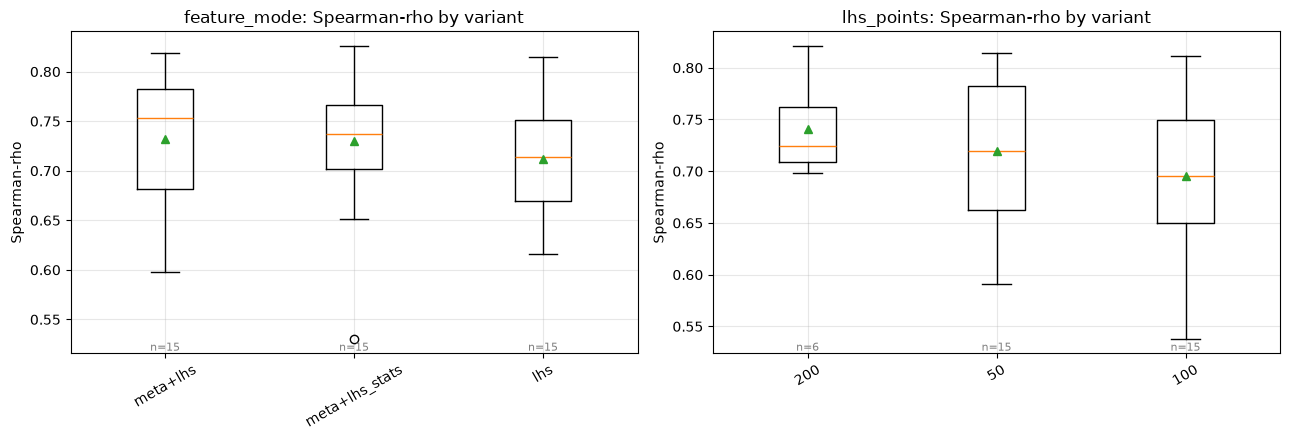

In [20]:
if HAS_DATA:
    studies = list(all_results["study"].unique())
    fig, axes = plt.subplots(
        1, len(studies), figsize=(6.5 * len(studies), 4.5), squeeze=False
    )
    for ax, study in zip(axes[0], studies):
        sub = all_results[all_results["study"] == study]
        variants_order = sorted(
            sub["variant"].unique(),
            key=lambda v: -sub.loc[sub["variant"] == v, "spearman_rho"].mean(),
        )
        data = [
            sub.loc[sub["variant"] == v, "spearman_rho"].values for v in variants_order
        ]
        ax.boxplot(data, showmeans=True)
        ax.set_xticks(range(1, len(variants_order) + 1), variants_order)
        for i, v in enumerate(variants_order, start=1):
            n = len(sub[sub["variant"] == v])
            ax.annotate(
                f"n={n}",
                (i, ax.get_ylim()[0]),
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray",
            )
        ax.set_title(f"{study}: Spearman-rho by variant")
        ax.set_ylabel("Spearman-rho")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No results loaded yet.")


## 5. Does it depend on which region was held out?

Mean Spearman-rho for each `(variant, holdout)` pair -- if a variant's
edge only shows up for one held-out region and not the others, that's a
sign of an idiosyncratic result rather than a real, general effect (see
`run_ablation.py`'s module docstring on why the default holdout sets
deliberately span different COCO/BBOB groups).


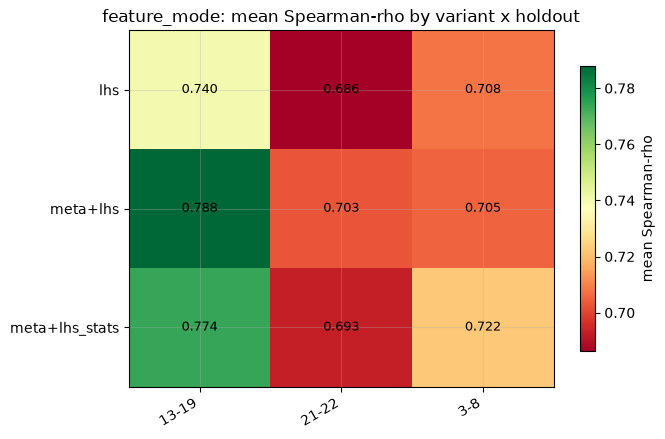

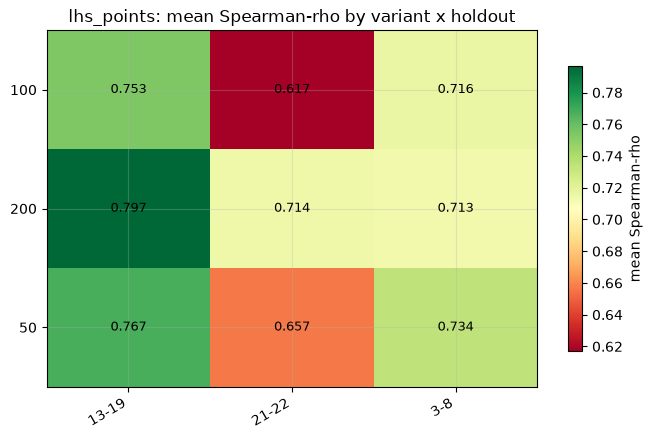

In [21]:
if HAS_DATA:
    for study in all_results["study"].unique():
        sub = all_results[all_results["study"] == study]
        pivot = sub.pivot_table(
            index="variant", columns="holdout_label", values="spearman_rho", aggfunc="mean"
        )
        if pivot.empty:
            continue
        fig, ax = plt.subplots(figsize=(1.6 * len(pivot.columns) + 2, 1.0 * len(pivot.index) + 1.5))
        im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")
        ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
        ax.set_yticks(range(len(pivot.index)), pivot.index)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)
        ax.set_title(f"{study}: mean Spearman-rho by variant x holdout")
        fig.colorbar(im, ax=ax, shrink=0.8, label="mean Spearman-rho")
        plt.tight_layout()
        plt.show()
else:
    print("No results loaded yet.")


## 6. Wall-clock so far

Mean total wall-clock (pipeline + train + eval) per finished run, by
variant -- useful for re-estimating how much longer the rest of the
matrix will take, and for sanity-checking that no variant is
mysteriously far slower than the others (it shouldn't be: feature-mode
and LHS-point-count changes only affect input *text length*, not model
size or step count).


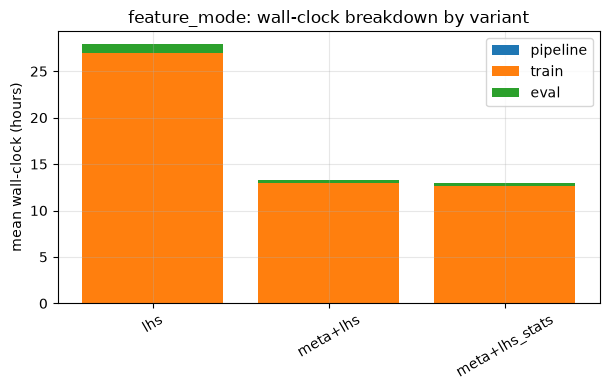

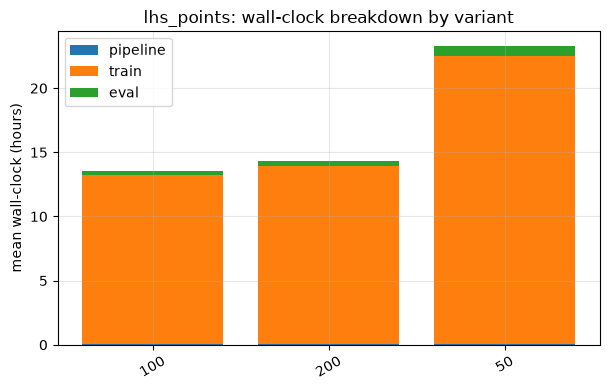

In [22]:
if HAS_DATA:
    for study in all_results["study"].unique():
        sub = all_results[all_results["study"] == study]
        wc_cols = ["pipeline", "train", "eval"]
        stage_means = {}
        for stage in wc_cols:
            stage_means[stage] = sub["wall_clock_seconds"].apply(
                lambda d, s=stage: (d or {}).get(s, np.nan)
            )
        stage_df = pd.DataFrame(stage_means)
        stage_df["variant"] = sub["variant"].values
        by_variant_h = stage_df.groupby("variant")[wc_cols].mean() / 3600

        fig, ax = plt.subplots(figsize=(1.4 * len(by_variant_h) + 2, 4))
        bottom = np.zeros(len(by_variant_h))
        for stage in wc_cols:
            ax.bar(by_variant_h.index, by_variant_h[stage], bottom=bottom, label=stage)
            bottom += by_variant_h[stage].values
        ax.set_ylabel("mean wall-clock (hours)")
        ax.set_title(f"{study}: wall-clock breakdown by variant")
        ax.legend()
        ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()
else:
    print("No results loaded yet.")


## 7. Aggregated vs. raw instance-level correlation

`spearman_rho` is computed after `aggregate_instance_predictions` rolls
exploded per-instance rows back to one prediction per candidate;
`instance_level.spearman_rho` (when present -- only if `evaluate.py` was
run with instance-level reporting) is the raw, un-aggregated signal. A
big, consistent gap between the two is worth understanding before trusting
either number.


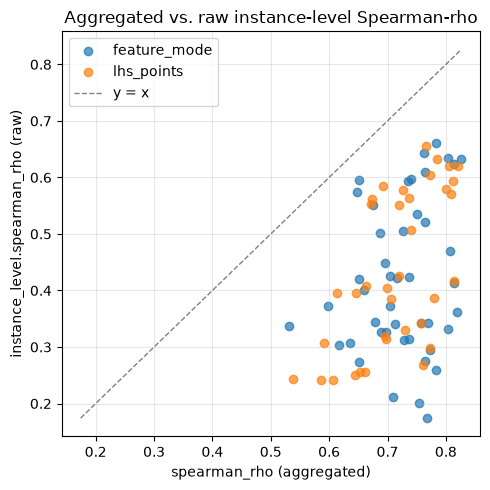

In [23]:
if HAS_DATA and all_results["instance_level_spearman"].notna().any():
    sub = all_results.dropna(subset=["instance_level_spearman"])
    fig, ax = plt.subplots(figsize=(5, 5))
    for study, group in sub.groupby("study"):
        ax.scatter(group["spearman_rho"], group["instance_level_spearman"], label=study, alpha=0.7)
    lo = min(sub["spearman_rho"].min(), sub["instance_level_spearman"].min())
    hi = max(sub["spearman_rho"].max(), sub["instance_level_spearman"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1, label="y = x")
    ax.set_xlabel("spearman_rho (aggregated)")
    ax.set_ylabel("instance_level.spearman_rho (raw)")
    ax.set_title("Aggregated vs. raw instance-level Spearman-rho")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif HAS_DATA:
    print("No instance_level data in any loaded result yet.")
else:
    print("No results loaded yet.")


## 7b. Dissecting the aggregated-vs-instance-level gap by variant

Why these two numbers can diverge: `spearman_rho` (aggregated) first
averages each candidate's raw per-instance predictions together, then
correlates that against the candidate's true `fitness`; `instance_level.
spearman_rho` correlates every raw per-instance prediction individually,
pooled across every held-out problem instance. Averaging several noisy
per-instance predictions per candidate mechanically reduces variance (the
same reason ensembling works), so the aggregated number being
consistently higher isn't by itself a red flag -- but a *bigger* gap for
one variant than another, or a trend with `n_lhs_points`, is worth
understanding. It also matters for expectations: if real downstream
pre-screening will average over *fewer* instances per candidate than
training/eval did here, the signal you'll actually see in practice sits
somewhere between instance-level and aggregated -- closer to
instance-level the fewer instances you average over.


In [24]:
if HAS_DATA and all_results["instance_level_spearman"].notna().any():
    gap_df = all_results.dropna(subset=["instance_level_spearman"]).copy()
    gap_df["agg_minus_instance_gap"] = (
        gap_df["spearman_rho"] - gap_df["instance_level_spearman"]
    )

    for study in gap_df["study"].unique():
        sub = gap_df[gap_df["study"] == study]
        print(f"=== {study} ===")
        summary = sub.groupby("variant").agg(
            n_runs=("agg_minus_instance_gap", "size"),
            aggregated_mean=("spearman_rho", "mean"),
            instance_level_mean=("instance_level_spearman", "mean"),
            gap_mean=("agg_minus_instance_gap", "mean"),
            gap_std=("agg_minus_instance_gap", "std"),
        ).sort_values("gap_mean", ascending=False)
        display(summary)
        print()
else:
    print("No instance_level data in any loaded result yet.")


=== feature_mode ===


,n_runs,aggregated_mean,instance_level_mean,gap_mean,gap_std
variant,,,,,
meta+lhs_stats,15,0.729618,0.394179,0.335440,0.153872
meta+lhs,15,0.731981,0.416082,0.315899,0.143611
lhs,15,0.711489,0.451545,0.259943,0.107936



=== lhs_points ===


,n_runs,aggregated_mean,instance_level_mean,gap_mean,gap_std
variant,,,,,
50,15,0.719250,0.428291,0.290960,0.113659
200,6,0.741071,0.467601,0.273470,0.107826
100,15,0.695480,0.428527,0.266953,0.116267


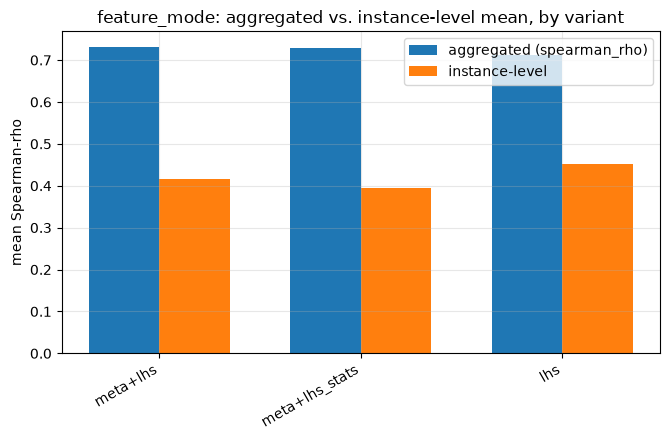

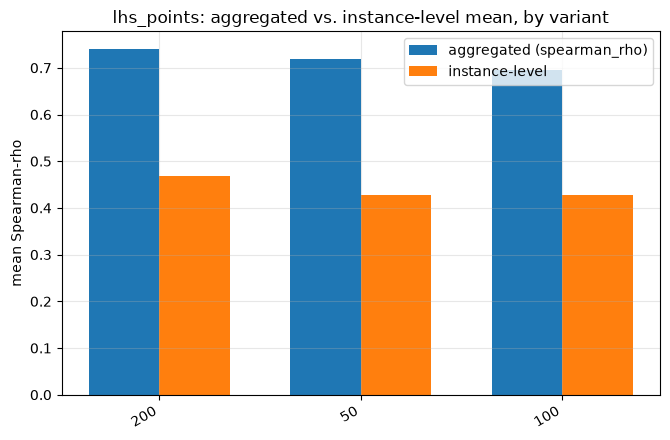

In [25]:
if HAS_DATA and all_results["instance_level_spearman"].notna().any():
    gap_df = all_results.dropna(subset=["instance_level_spearman"])
    for study in gap_df["study"].unique():
        sub = gap_df[gap_df["study"] == study]
        variants_order = sorted(
            sub["variant"].unique(),
            key=lambda v: -sub.loc[sub["variant"] == v, "spearman_rho"].mean(),
        )
        agg_means = [
            sub.loc[sub["variant"] == v, "spearman_rho"].mean() for v in variants_order
        ]
        inst_means = [
            sub.loc[sub["variant"] == v, "instance_level_spearman"].mean()
            for v in variants_order
        ]

        x = np.arange(len(variants_order))
        width = 0.35
        fig, ax = plt.subplots(figsize=(1.6 * len(variants_order) + 2, 4.5))
        ax.bar(x - width / 2, agg_means, width, label="aggregated (spearman_rho)")
        ax.bar(x + width / 2, inst_means, width, label="instance-level")
        ax.set_xticks(x, variants_order, rotation=30, ha="right")
        ax.set_ylabel("mean Spearman-rho")
        ax.set_title(f"{study}: aggregated vs. instance-level mean, by variant")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No instance_level data in any loaded result yet.")


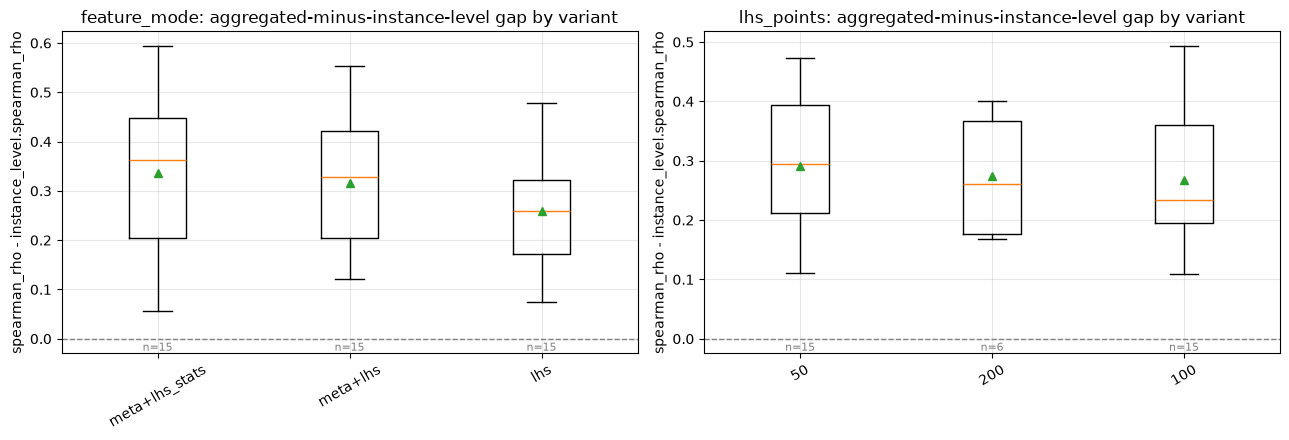

In [26]:
if HAS_DATA and all_results["instance_level_spearman"].notna().any():
    gap_df = all_results.dropna(subset=["instance_level_spearman"]).copy()
    gap_df["agg_minus_instance_gap"] = (
        gap_df["spearman_rho"] - gap_df["instance_level_spearman"]
    )
    studies = list(gap_df["study"].unique())
    fig, axes = plt.subplots(
        1, len(studies), figsize=(6.5 * len(studies), 4.5), squeeze=False
    )
    for ax, study in zip(axes[0], studies):
        sub = gap_df[gap_df["study"] == study]
        variants_order = sorted(
            sub["variant"].unique(),
            key=lambda v: -sub.loc[sub["variant"] == v, "agg_minus_instance_gap"].mean(),
        )
        data = [
            sub.loc[sub["variant"] == v, "agg_minus_instance_gap"].values
            for v in variants_order
        ]
        ax.boxplot(data, showmeans=True)
        ax.set_xticks(range(1, len(variants_order) + 1), variants_order)
        ax.axhline(0, color="gray", linewidth=1, linestyle="--")
        for i, v in enumerate(variants_order, start=1):
            n = len(sub[sub["variant"] == v])
            ax.annotate(
                f"n={n}",
                (i, ax.get_ylim()[0]),
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray",
            )
        ax.set_title(f"{study}: aggregated-minus-instance-level gap by variant")
        ax.set_ylabel("spearman_rho - instance_level.spearman_rho")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No instance_level data in any loaded result yet.")


,mean,std,count
n_lhs_points,,,
50.0,0.290960,0.113659,15
100.0,0.266953,0.116267,15
200.0,0.273470,0.107826,6


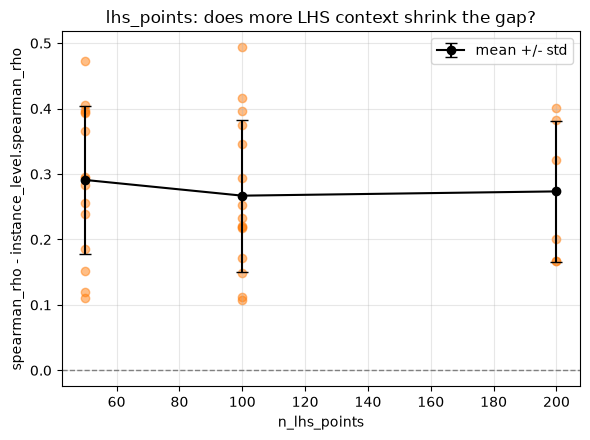

In [27]:
if HAS_DATA and "lhs_points" in all_results["study"].unique():
    sub = (
        all_results[all_results["study"] == "lhs_points"]
        .dropna(subset=["instance_level_spearman"])
        .copy()
    )
    if len(sub):
        sub["agg_minus_instance_gap"] = (
            sub["spearman_rho"] - sub["instance_level_spearman"]
        )
        by_points = sub.groupby("n_lhs_points")["agg_minus_instance_gap"].agg(
            ["mean", "std", "count"]
        )
        display(by_points)

        fig, ax = plt.subplots(figsize=(6, 4.5))
        for n_points, group in sub.groupby("n_lhs_points"):
            ax.scatter(
                [n_points] * len(group),
                group["agg_minus_instance_gap"],
                alpha=0.5,
                color="tab:orange",
            )
        ax.errorbar(
            by_points.index,
            by_points["mean"],
            yerr=by_points["std"],
            fmt="o-",
            color="black",
            capsize=4,
            label="mean +/- std",
        )
        ax.axhline(0, color="gray", linewidth=1, linestyle="--")
        ax.set_xlabel("n_lhs_points")
        ax.set_ylabel("spearman_rho - instance_level.spearman_rho")
        ax.set_title("lhs_points: does more LHS context shrink the gap?")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No instance_level data for the lhs_points study yet.")
else:
    print("lhs_points study not loaded (or no data yet).")


## 8. Raw results table

Every loaded run, most recent Spearman-rho first -- for filtering/sorting
by hand, or spotting an odd outlier run worth opening directly (see its
`result_path`/`run_dir`).


In [28]:
if HAS_DATA:
    display_cols = [
        "study", "variant", "seed", "holdout_label", "spearman_rho", "kendall_tau",
        "n_test", "wall_clock_total_h", "result_path",
    ]
    display(all_results[display_cols].sort_values("spearman_rho", ascending=False))
else:
    print("No results loaded yet.")


,study,variant,seed,holdout_label,spearman_rho,kendall_tau,n_test,wall_clock_total_h,result_path
33,feature_mode,meta+lhs_stats,1,13-19,0.825894,0.656735,616,14.480621,/data/neocortex/rlm/results/ablation/meta_lhs_...
60,lhs_points,200,0,13-19,0.821066,0.636872,720,13.761983,/data/neocortex/rlm/results/ablation_lhs_point...
27,feature_mode,meta+lhs,4,13-19,0.818354,0.637197,532,14.613354,/data/neocortex/rlm/results/ablation/meta_lhs_...
3,feature_mode,lhs,1,13-19,0.814568,0.625653,2060,33.148170,/data/neocortex/rlm/results/ablation/lhs__seed...
36,feature_mode,meta+lhs_stats,2,13-19,0.814556,0.645167,612,12.588988,/data/neocortex/rlm/results/ablation/meta_lhs_...
...,...,...,...,...,...,...,...,...,...
25,feature_mode,meta+lhs,3,21-22,0.597741,0.434604,620,12.695167,/data/neocortex/rlm/results/ablation/meta_lhs_...
73,lhs_points,50,2,21-22,0.591464,0.424096,2200,34.177320,/data/neocortex/rlm/results/ablation_lhs_point...
58,lhs_points,100,4,21-22,0.586466,0.422648,532,11.732364,/data/neocortex/rlm/results/ablation_lhs_point...
52,lhs_points,100,2,21-22,0.538090,0.384073,612,14.142339,/data/neocortex/rlm/results/ablation_lhs_point...


## 9. (Optional) Export a merged CSV

Handy for sharing a snapshot outside this notebook, or plugging into
another tool.


In [29]:
if HAS_DATA:
    out_path = Path("results/ablation_explorer_snapshot.csv")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    export_cols = [c for c in all_results.columns if c not in ("instance_explosion", "wall_clock_seconds", "instance_level")]
    all_results[export_cols].to_csv(out_path, index=False)
    print(f"Wrote {len(all_results)} row(s) to {out_path}")
else:
    print("No results loaded yet.")


Wrote 81 row(s) to results/ablation_explorer_snapshot.csv


## Notes

- This notebook never blocks on or triggers a run -- it's read-only over
  whatever `ablation_result.json` files already exist. Re-run it anytime;
  newly-finished runs (including ones written by other GPU workers under
  `--gpus`) just show up.
- A `"variant"` of a plain number (e.g. `"50"`) in the `lhs_points` study
  is the `n_lhs_points` value, not a feature mode -- see
  `run_ablation_lhs_points.py`'s docstring.
- Once a clear winner emerges with comparable seed/holdout coverage
  across variants, rerun it with `data_pipeline.py`'s and `train.py`'s
  normal (larger, non-ablation) budget for the real result -- these
  numbers come from the short-training-budget ranking pass, not a
  converged model.
